In [ ]:
!pip install langgraph
!pip install langchain
!pip install langchain_google_genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 2.7 MB/s eta 0:00:00


In [ ]:
pip install langchain_openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.7/506.7 kB 14.2 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.19
    Uninstalling langchain-core-1.2.19:
      Successfully uninstalled langchain-core-1.2.19


In [ ]:
from google.colab import userdata
import os
os.environ['GOOGLE_GENAI_PROJECT'] = userdata.get('gemini')
os.environ['OPENAI_API_KEY']=userdata.get('openai')

In [ ]:
import random

In [ ]:
from typing import TypedDict,Annotated
from langgraph.graph import StateGraph,START,END
from operator import add

In [ ]:
# State Schema
class Data(TypedDict):
  rn:int
  count:int
  quote:Annotated[list[str],add]

In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini",temperature=0.7)

In [ ]:
llm.invoke("create a beautiful quote").content

'"Amidst the chaos of life, let your heart be a garden where kindness blooms and love takes root, for it is in the smallest acts of grace that we find the deepest connections."'

In [ ]:
graph=StateGraph(state_schema=Data)

In [ ]:
# 1 node
def random_gen(state:Data):
  return {'rn':random.randint(10,20)}
# 2 node
def quote_gen(state:Data):
  state['quote']=[llm.invoke("create a beautiful quote").content]
  state["count"]=state["count"] + 1

# 3 Condition
def condition(state:Data):
  if state["rn"]>=10:
    return "true"
  else:
    return "false"
# add all the nodes

graph.add_node("random",random_gen)
graph.add_node("quote",quote_gen)

# add all the edges

graph.add_edge(START,"random")
graph.add_conditional_edges("random",condition,{"true":"quote","false":END})
graph.add_edge("quote","random")


In [ ]:
flow=graph.compile()


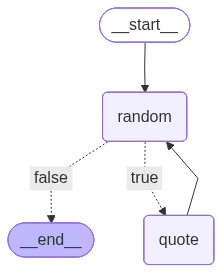

In [ ]:
flow

In [ ]:
flow.invoke({"count":0})

KeyboardInterrupt: 